# 🍌 Banana Pipeline — Segmentation + Ripeness Classification

**Pipeline Overview:**
1. Load a group banana image
2. Mask R-CNN segments each individual banana → binary masks + bounding boxes
3. Each banana is cropped using its mask
4. MobileNetV2 classifies each crop as: `unripe`, `ripe`, `overripe`, or `rotten`
5. Results are visualised with per-banana labels, confidence scores, and a summary

**Models required (saved from training):**
- `banana_maskrcnn_finetuned.pth` — fine-tuned Mask R-CNN (segmentation)
- `banana_mobilenetv2_best.pth` — best MobileNetV2 checkpoint (ripeness)

## Step 0 — Mount Drive & Install Dependencies

In [1]:
# Mount Google Drive FIRST — models are loaded from here
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Set random seeds for full reproducibility
import torch
import numpy as np
import random

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Seeds set. Reproducibility enabled.")

Seeds set. Reproducibility enabled.


## Step 1 — Imports

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import models
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageEnhance, ImageDraw, ImageFont
from google.colab import files

print("All imports successful.")
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

All imports successful.
PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


## Step 2 — Configuration

Edit the paths below to match where your `.pth` files are saved in Drive.

In [4]:
# ─── PATH CONFIGURATION ────────────────────────────────────────────────────
SEGMENTATION_MODEL_PATH = "/content/drive/MyDrive/banana_maskrcnn_finetuned.pth"
RIPENESS_MODEL_PATH     = "/content/drive/MyDrive/banana_mobilenetv2_best.pth"

# ─── SEGMENTATION THRESHOLDS ───────────────────────────────────────────────
SEG_SCORE_THRESHOLD  = 0.85   # Mask R-CNN confidence to accept a detection
SEG_MASK_THRESHOLD   = 0.5    # Probability threshold to binarise the soft mask
MIN_BANANA_AREA      = 1500   # Ignore masks smaller than this (px²) — filters noise

# ─── RIPENESS CLASSIFICATION THRESHOLDS ────────────────────────────────────
RIPENESS_CONF_THRESHOLD  = 0.60   # Below this → flag as low-confidence
EXPOSURE_DARK_THRESHOLD  = 60     # Mean pixel value below this → boost brightness
EXPOSURE_BRIGHT_THRESHOLD = 200   # Mean pixel value above this → reduce brightness

# ─── PIPELINE BEHAVIOUR ────────────────────────────────────────────────────
BANANA_CLASS_ID  = 1    # Class index used during fine-tuning (1 = banana, 0 = bg)
NUM_RIPENESS_CLASSES = 4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {DEVICE}")

Running on: cuda


## Step 3 — Load the Segmentation Model (Mask R-CNN)

In [5]:
def load_segmentation_model(weights_path: str, device: torch.device) -> torch.nn.Module:
    """
    Rebuilds the fine-tuned Mask R-CNN exactly as it was defined during training,
    then loads the saved state dict.
    """
    # 1. Base architecture with no pretrained weights (we load our own below)
    model = maskrcnn_resnet50_fpn(weights=None)

    # 2. Replace box predictor — must match training (num_classes=2: bg + banana)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

    # 3. Replace mask predictor — must match training
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, 256, 2
    )

    # 4. Load weights
    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()
    print(f"Segmentation model loaded from: {weights_path}")
    return model


seg_model = load_segmentation_model(SEGMENTATION_MODEL_PATH, DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


Segmentation model loaded from: /content/drive/MyDrive/banana_maskrcnn_finetuned.pth


## Step 4 — Load the Ripeness Model (MobileNetV2)

In [6]:
def load_ripeness_model(weights_path: str, device: torch.device, num_classes: int = 4) -> torch.nn.Module:
    """
    Rebuilds MobileNetV2 with a replaced 4-class classifier head,
    then loads the saved state dict.
    """
    model = models.mobilenet_v2(weights=None)

    # Replace classifier head — must match training
    num_features = model.classifier[1].in_features  # 1280
    model.classifier[1] = nn.Linear(num_features, num_classes)

    state_dict = torch.load(weights_path, map_location=device)
    model.load_state_dict(state_dict)

    model.to(device)
    model.eval()
    print(f"Ripeness model loaded from: {weights_path}")
    return model


ripeness_model = load_ripeness_model(RIPENESS_MODEL_PATH, DEVICE, num_classes=NUM_RIPENESS_CLASSES)

# ── Class label mapping — derived safely (no hardcoding) ───────────────────
# The ImageFolder sorts classes alphabetically, so the order is always:
# overripe=0, ripe=1, rotten=2, unripe=3
# We reconstruct this the same way torchvision.datasets.ImageFolder does.
IDX_TO_CLASS = {0: 'overripe', 1: 'ripe', 2: 'rotten', 3: 'unripe'}
# If you have access to the training dataset object, override with:
#   IDX_TO_CLASS = {v: k for k, v in train_dataset.class_to_idx.items()}
print("Class mapping:", IDX_TO_CLASS)

Ripeness model loaded from: /content/drive/MyDrive/banana_mobilenetv2_best.pth
Class mapping: {0: 'overripe', 1: 'ripe', 2: 'rotten', 3: 'unripe'}


## Step 5 — Helper Functions

In [7]:
# ─── INFERENCE TRANSFORM (ripeness model input) ────────────────────────────
inference_transform = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ─── DETERMINISTIC TTA TRANSFORMS ─────────────────────────────────────────
# Fixed transforms only — no Random* to ensure reproducibility.
tta_transforms = [
    # 1. Standard centre crop
    T.Compose([
        T.Resize(256), T.CenterCrop(224),
        T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 2. Horizontal flip (deterministic)
    T.Compose([
        T.Resize(256), T.CenterCrop(224),
        T.Lambda(lambda img: TF.hflip(img)),
        T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 3. Slightly larger scale
    T.Compose([
        T.Resize(280), T.CenterCrop(224),
        T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 4. Fixed +10° rotation (Lambda, not RandomRotation)
    T.Compose([
        T.Resize(256), T.CenterCrop(224),
        T.Lambda(lambda img: TF.rotate(img, 10)),
        T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    # 5. Fixed -10° rotation
    T.Compose([
        T.Resize(256), T.CenterCrop(224),
        T.Lambda(lambda img: TF.rotate(img, -10)),
        T.ToTensor(), T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
]


def auto_correct_exposure(pil_img: Image.Image):
    """
    Normalises extremely dark or bright images before classification.
    Returns (corrected_img, tag_string).
    """
    arr  = np.array(pil_img.convert('L'))
    mean = arr.mean()
    tag  = ""
    if mean < EXPOSURE_DARK_THRESHOLD:
        factor  = min(2.5, 120.0 / (mean + 1e-6))
        pil_img = ImageEnhance.Brightness(pil_img).enhance(factor)
        tag     = f"[low-light corrected, mean={mean:.0f}]"
    elif mean > EXPOSURE_BRIGHT_THRESHOLD:
        factor  = max(0.5, 160.0 / (mean + 1e-6))
        pil_img = ImageEnhance.Brightness(pil_img).enhance(factor)
        tag     = f"[high-light corrected, mean={mean:.0f}]"
    return pil_img, tag


def predict_ripeness_with_tta(
    crop_pil: Image.Image,
    model: torch.nn.Module,
    device: torch.device,
):
    """
    Runs TTA over a single cropped banana PIL image.
    Returns (predicted_idx, confidence_float, all_class_probs_array).
    """
    all_probs = []
    with torch.no_grad():
        for tfm in tta_transforms:
            tensor = tfm(crop_pil).unsqueeze(0).to(device)
            logits = model(tensor)
            probs  = F.softmax(logits, dim=1)
            all_probs.append(probs)
    avg_probs  = torch.stack(all_probs).mean(dim=0)          # (1, 4)
    conf, idx  = torch.max(avg_probs, dim=1)
    return idx.item(), conf.item(), avg_probs.squeeze().cpu().numpy()


def extract_tight_crop(
    image_np: np.ndarray,
    binary_mask: np.ndarray,
    padding: int = 10,
) -> Image.Image:
    h, w = binary_mask.shape

    ys, xs = np.where(binary_mask)
    if len(ys) == 0 or len(xs) == 0:
        return Image.fromarray(image_np)

    y1 = max(0, ys.min() - padding)
    y2 = min(h, ys.max() + padding)
    x1 = max(0, xs.min() - padding)
    x2 = min(w, xs.max() + padding)

    cropped_img  = image_np[y1:y2, x1:x2].copy()
    cropped_mask = binary_mask[y1:y2, x1:x2]

    # ✅ APPLY the mask — zero out everything outside the banana
    cropped_img[~cropped_mask] = 0  # or = 255 for white background

    return Image.fromarray(cropped_img)


print("Helper functions defined.")

Helper functions defined.


## Step 6 — Core Pipeline Function

In [8]:
def run_banana_pipeline(
    image_path: str,
    seg_model: torch.nn.Module,
    ripeness_model: torch.nn.Module,
    device: torch.device,
) -> dict:
    """
    Full pipeline: image → segmentation → per-banana ripeness classification.

    Returns a dict:
    {
        'image_np'      : np.ndarray  (H, W, 3),
        'results'       : list of per-banana dicts,
        'num_detected'  : int,
    }

    Each per-banana dict contains:
    {
        'banana_id'    : int (1-indexed),
        'seg_score'    : float  (Mask R-CNN confidence),
        'bbox'         : [x1, y1, x2, y2],
        'binary_mask'  : np.ndarray bool (H, W),
        'crop_pil'     : PIL.Image,
        'ripeness'     : str  ('unripe' / 'ripe' / 'overripe' / 'rotten'),
        'confidence'   : float,
        'all_probs'    : np.ndarray (4,),
        'low_conf'     : bool,
        'exposure_tag' : str,
    }
    """

    # ── 1. Load image ───────────────────────────────────────────────────────
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    image_np = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # ── 2. Segmentation ─────────────────────────────────────────────────────
    img_tensor = TF.to_tensor(image_np).to(device)

    with torch.no_grad():
        predictions = seg_model([img_tensor])

    pred    = predictions[0]
    labels  = pred['labels']
    scores  = pred['scores']
    masks   = pred['masks']   # shape: (N, 1, H, W), float [0, 1]
    boxes   = pred['boxes']   # shape: (N, 4)

    # Filter by class (banana=1) and confidence threshold
    keep = (labels == BANANA_CLASS_ID) & (scores > SEG_SCORE_THRESHOLD)
    masks  = masks[keep]
    scores = scores[keep]
    boxes  = boxes[keep]

    print(f"Segmentation: {keep.sum().item()} banana(s) detected above threshold {SEG_SCORE_THRESHOLD}.")

    # ── 3. Per-banana ripeness classification ───────────────────────────────
    results = []
    banana_id = 1

    for i in range(len(masks)):
        binary_mask = (masks[i, 0] > SEG_MASK_THRESHOLD).cpu().numpy()  # bool (H, W)

        # Skip tiny masks (segmentation noise)
        mask_area = binary_mask.sum()
        if mask_area < MIN_BANANA_AREA:
            print(f"  Skipping mask {i+1}: area {mask_area}px² < minimum {MIN_BANANA_AREA}px²")
            continue

        bbox = boxes[i].cpu().numpy().astype(int).tolist()

        # Crop the banana with masked background
        crop_pil = extract_tight_crop(image_np, binary_mask, padding=10)

        # Exposure correction on the crop (not the full image)
        corrected_crop, exposure_tag = auto_correct_exposure(crop_pil)

        # Ripeness prediction with deterministic TTA
        pred_idx, confidence, all_probs = predict_ripeness_with_tta(
            corrected_crop, ripeness_model, device
        )

        results.append({
            'banana_id'   : banana_id,
            'seg_score'   : scores[i].item(),
            'bbox'        : bbox,
            'binary_mask' : binary_mask,
            'crop_pil'    : crop_pil,           # original crop (for display)
            'ripeness'    : IDX_TO_CLASS[pred_idx],
            'confidence'  : confidence,
            'all_probs'   : all_probs,
            'low_conf'    : confidence < RIPENESS_CONF_THRESHOLD,
            'exposure_tag': exposure_tag,
        })
        banana_id += 1

    return {
        'image_np'    : image_np,
        'results'     : results,
        'num_detected': len(results),
    }


print("Pipeline function defined.")

Pipeline function defined.


## Step 7 — Visualisation Functions

In [9]:
# ─── Colour scheme per ripeness class ──────────────────────────────────────
RIPENESS_COLORS = {
    'unripe'   : (0,   200,  80),   # green
    'ripe'     : (255, 200,   0),   # yellow
    'overripe' : (255, 120,   0),   # orange
    'rotten'   : (180,  30,  30),   # red
}


def visualise_pipeline_results(pipeline_output: dict, save_path: str = None):
    """
    Produces two figures:
    1. Annotated full image — coloured overlays, bounding boxes, and per-banana labels.
    2. Individual crops — one panel per banana showing crop + probability bar chart.
    """
    image_np  = pipeline_output['image_np']
    results   = pipeline_output['results']
    n         = len(results)

    if n == 0:
        print("No bananas detected — nothing to visualise.")
        return

    # ── Figure 1: Annotated full image ──────────────────────────────────────
    overlay = image_np.copy()

    for r in results:
        color = RIPENESS_COLORS[r['ripeness']]
        mask  = r['binary_mask']

        # Colour-tinted mask overlay (alpha blend)
        colored_region = np.zeros_like(image_np)
        colored_region[mask] = color
        overlay = cv2.addWeighted(overlay, 1.0, colored_region, 0.45, 0)

        # Bounding box
        x1, y1, x2, y2 = r['bbox']
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, thickness=2)

        # Label above bounding box
        warn     = " ⚠" if r['low_conf'] else ""
        label    = f"#{r['banana_id']} {r['ripeness']} {r['confidence']*100:.0f}%{warn}"
        txt_y    = max(y1 - 8, 18)
        # Background pill for readability
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.55, 2)
        cv2.rectangle(overlay, (x1, txt_y - th - 4), (x1 + tw + 4, txt_y + 4),
                      color, thickness=-1)
        cv2.putText(overlay, label, (x1 + 2, txt_y),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 2, cv2.LINE_AA)

    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(overlay)
    ax.set_title(f"Banana Detection & Ripeness — {n} banana(s) found", fontsize=14, fontweight='bold')
    ax.axis('off')

    # Colour legend
    legend_patches = [
        mpatches.Patch(color=np.array(v)/255, label=k)
        for k, v in RIPENESS_COLORS.items()
    ]
    ax.legend(handles=legend_patches, loc='lower right', fontsize=10,
              framealpha=0.85, title="Ripeness")

    if save_path:
        fig.savefig(save_path.replace('.jpg', '_annotated.jpg'),
                    bbox_inches='tight', dpi=150)
    plt.tight_layout()
    plt.show()

    # ── Figure 2: Per-banana crop panels ────────────────────────────────────
    cols     = min(n, 4)     # max 4 per row
    rows     = (n + cols - 1) // cols
    fig2, axes = plt.subplots(rows, cols * 2, figsize=(cols * 5, rows * 4))

    # Flatten axes for easy indexing; handle single-row edge case
    if rows == 1 and cols * 2 == 2:
        axes = np.array([axes])
    axes = np.array(axes).reshape(rows, cols * 2)

    class_names = [IDX_TO_CLASS[i] for i in range(NUM_RIPENESS_CLASSES)]

    for idx, r in enumerate(results):
        row = idx // cols
        col = (idx % cols) * 2  # each banana uses 2 columns: image + bar

        # Left: crop image
        ax_img = axes[row, col]
        ax_img.imshow(r['crop_pil'])
        warn = " ⚠️ LOW CONF" if r['low_conf'] else ""
        exp  = f"\n{r['exposure_tag']}" if r['exposure_tag'] else ""
        ax_img.set_title(
            f"Banana #{r['banana_id']}\n"
            f"{r['ripeness']} ({r['confidence']*100:.1f}%){warn}{exp}",
            fontsize=10, fontweight='bold'
        )
        ax_img.axis('off')

        # Right: probability bar chart
        ax_bar = axes[row, col + 1]
        pred_label = r['ripeness']
        bar_colors = [
            np.array(RIPENESS_COLORS[cn]) / 255
            if cn == pred_label
            else np.array([0.8, 0.8, 0.8])
            for cn in class_names
        ]
        bars = ax_bar.barh(class_names, r['all_probs'] * 100, color=bar_colors)
        ax_bar.set_xlabel('Probability (%)', fontsize=9)
        ax_bar.set_title('Class Probabilities', fontsize=9)
        ax_bar.set_xlim(0, 100)
        for bar_i, v in enumerate(r['all_probs'] * 100):
            ax_bar.text(v + 0.5, bar_i, f'{v:.1f}%', va='center', fontsize=9)

        ax_bar.text(
            0.5, -0.15,
            f"Seg score: {r['seg_score']:.2f}",
            transform=ax_bar.transAxes,
            ha='center', fontsize=8, color='gray'
        )

    # Hide empty subplot slots
    total_slots = rows * cols
    for empty in range(n, total_slots):
        row = empty // cols
        col = (empty % cols) * 2
        axes[row, col].axis('off')
        axes[row, col + 1].axis('off')

    fig2.suptitle('Per-Banana Ripeness Analysis', fontsize=13, fontweight='bold', y=1.01)
    if save_path:
        fig2.savefig(save_path.replace('.jpg', '_crops.jpg'),
                     bbox_inches='tight', dpi=150)
    plt.tight_layout()
    plt.show()


def print_pipeline_summary(pipeline_output: dict):
    """
    Prints a clean text summary of all detections.
    """
    results = pipeline_output['results']
    n       = pipeline_output['num_detected']

    print("\n" + "="*55)
    print(f"   PIPELINE SUMMARY — {n} banana(s) detected")
    print("="*55)

    from collections import Counter
    class_counts = Counter(r['ripeness'] for r in results)

    for r in results:
        warn = " ⚠️  low confidence" if r['low_conf'] else ""
        exp  = f" {r['exposure_tag']}" if r['exposure_tag'] else ""
        print(f"  Banana #{r['banana_id']:>2} | "
              f"ripeness: {r['ripeness']:<10} | "
              f"conf: {r['confidence']*100:5.1f}% | "
              f"seg: {r['seg_score']:.2f}"
              f"{warn}{exp}")

    print("-"*55)
    print("  Class breakdown:")
    for cls, cnt in sorted(class_counts.items()):
        print(f"    {cls:<10}: {cnt}")
    print("="*55 + "\n")


print("Visualisation functions defined.")

Visualisation functions defined.


## Step 8 — Run the Pipeline on Your Image

Upload a group banana image:


Saving Screenshot 2026-04-16 144546.png to Screenshot 2026-04-16 144546.png

Processing: Screenshot 2026-04-16 144546.png
Segmentation: 7 banana(s) detected above threshold 0.85.

   PIPELINE SUMMARY — 7 banana(s) detected
  Banana # 1 | ripeness: rotten     | conf:  99.9% | seg: 1.00 [low-light corrected, mean=34]
  Banana # 2 | ripeness: ripe       | conf:  92.4% | seg: 1.00
  Banana # 3 | ripeness: rotten     | conf: 100.0% | seg: 0.99 [low-light corrected, mean=23]
  Banana # 4 | ripeness: rotten     | conf:  98.8% | seg: 0.99 [low-light corrected, mean=49]
  Banana # 5 | ripeness: ripe       | conf:  90.2% | seg: 0.99
  Banana # 6 | ripeness: rotten     | conf: 100.0% | seg: 0.99 [low-light corrected, mean=20]
  Banana # 7 | ripeness: rotten     | conf:  54.5% | seg: 0.97 ⚠️  low confidence [low-light corrected, mean=57]
-------------------------------------------------------
  Class breakdown:
    ripe      : 2
    rotten    : 5



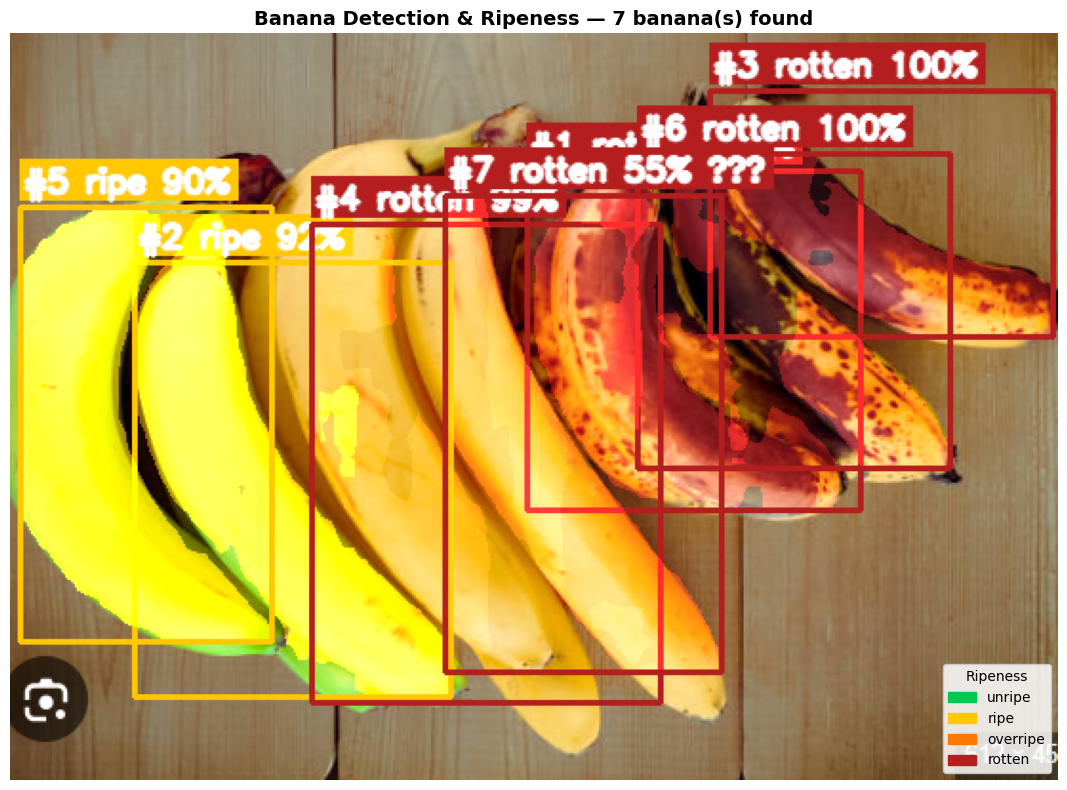

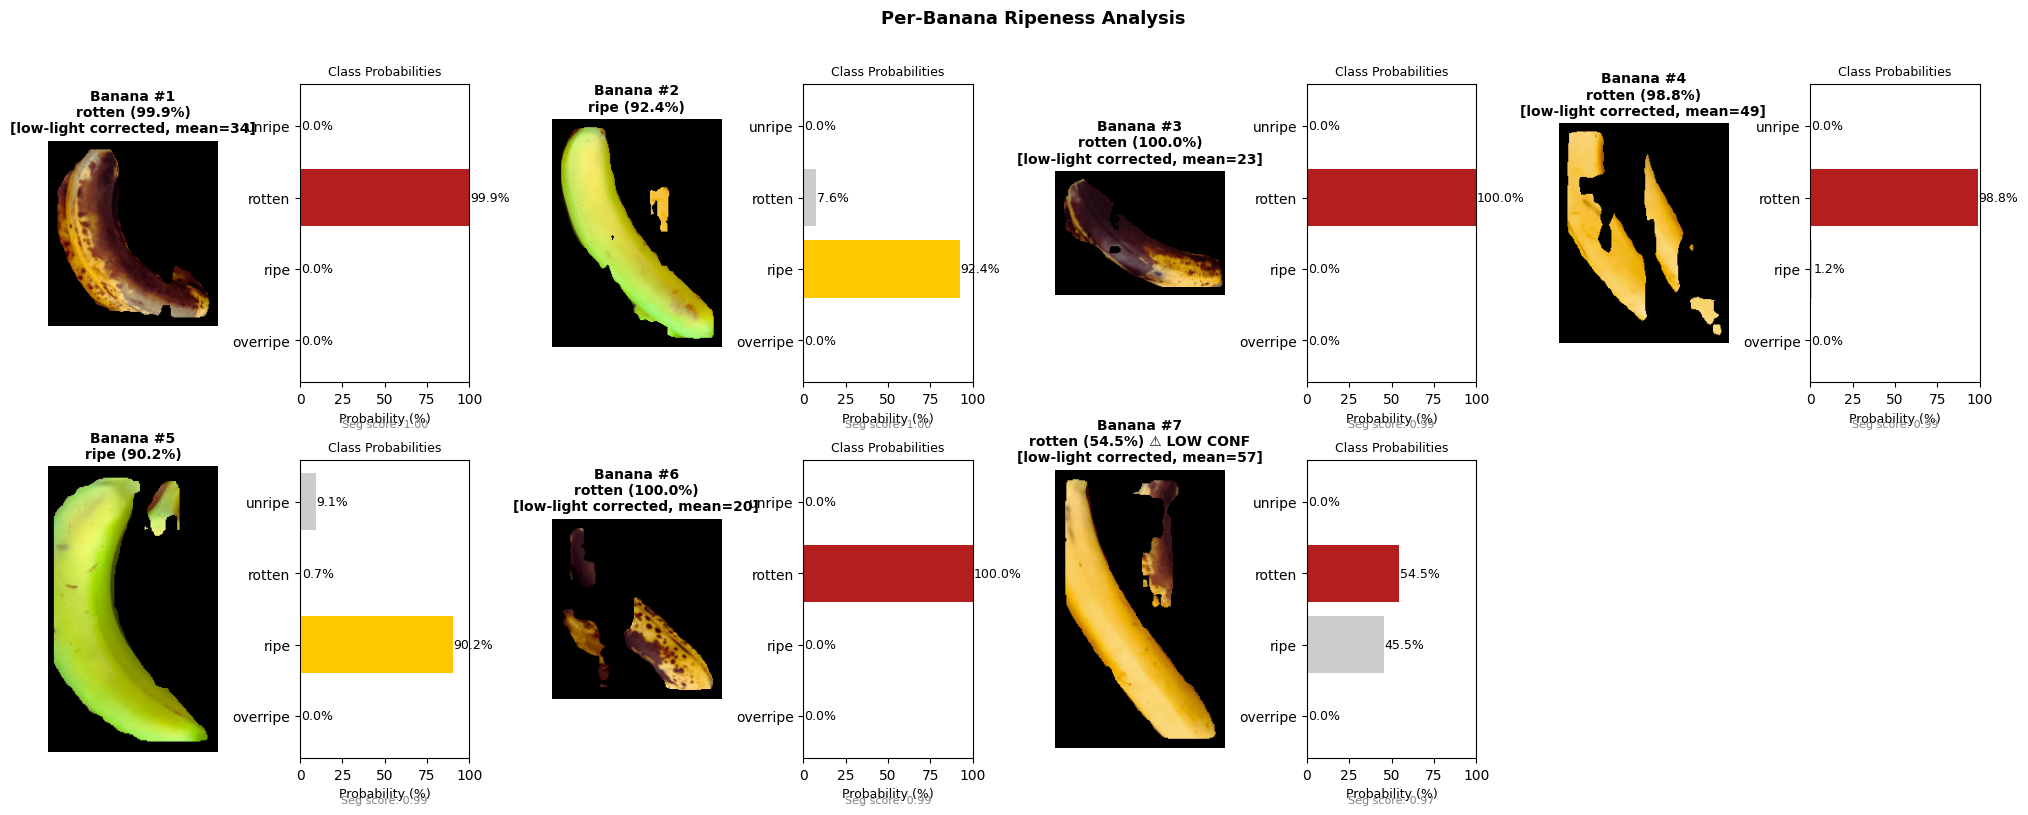

In [12]:
# Upload one or more group banana images
print("Upload a group banana image:")
uploaded = files.upload()

for file_name in uploaded.keys():
    print(f"\nProcessing: {file_name}")

    # Run the full pipeline
    output = run_banana_pipeline(
        image_path=file_name,
        seg_model=seg_model,
        ripeness_model=ripeness_model,
        device=DEVICE,
    )

    # Print summary
    print_pipeline_summary(output)

    # Visualise (pass save_path to also save figures to Drive)
    visualise_pipeline_results(
        output,
        save_path=f"/content/drive/MyDrive/{file_name}"
    )

## Step 9 — (Optional) Batch Inference on a Folder

In [11]:
import os

def run_batch(
    image_folder: str,
    seg_model: torch.nn.Module,
    ripeness_model: torch.nn.Module,
    device: torch.device,
    extensions: tuple = ('.jpg', '.jpeg', '.png'),
):
    """
    Runs the pipeline over every image in a folder.
    Prints a combined summary table at the end.
    """
    image_paths = [
        os.path.join(image_folder, f)
        for f in sorted(os.listdir(image_folder))
        if f.lower().endswith(extensions)
    ]

    print(f"Found {len(image_paths)} images in {image_folder}")

    all_results = []

    for path in image_paths:
        try:
            output = run_banana_pipeline(path, seg_model, ripeness_model, device)
            print_pipeline_summary(output)
            visualise_pipeline_results(output)
            all_results.append({'file': os.path.basename(path), **output})
        except Exception as e:
            print(f"  ERROR processing {path}: {e}")

    return all_results


# Uncomment and set your folder path to use batch mode:
# batch_results = run_batch(
#     image_folder="/content/drive/MyDrive/test_images/",
#     seg_model=seg_model,
#     ripeness_model=ripeness_model,
#     device=DEVICE,
# )

print("Batch inference function ready (uncomment above to run).")

Batch inference function ready (uncomment above to run).
